In [ ]:
import pandas as pd
import numpy as np
import os
import time
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns


bestTest = 0.7769685757
bestIteration = 991

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.

bestTest = 0.7769483693
bestIteration = 999

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.

bestTest = 0.7752631845
bestIteration = 999

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.
Training on fold [0/3]

bestTest = 0.7771378724
bestIteration = 998

Training on fold [1/3]

bestTest = 0.7740480277
bestIteration = 997

Training on fold [2/3]

bestTest = 0.7762882437
bestIteration = 997


✅ ПЕРЕБОР ЗАВЕРШЕН!
Время выполнения: 83.7 минут

Лучшие гиперпараметры:
  - depth: 8
  - learning_rate: 0.05
  - l2_leaf_reg: 3
  - iterations: 1000

ОЦЕНКА НА ТЕСТОВОЙ ВЫБОРКЕ (Test Set)
ROC-AUC: 0.7780

Отчет классификации:
              precision  

C:\Users\danii\AppData\Local\Temp\ipykernel_28340\2566462544.py:126: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


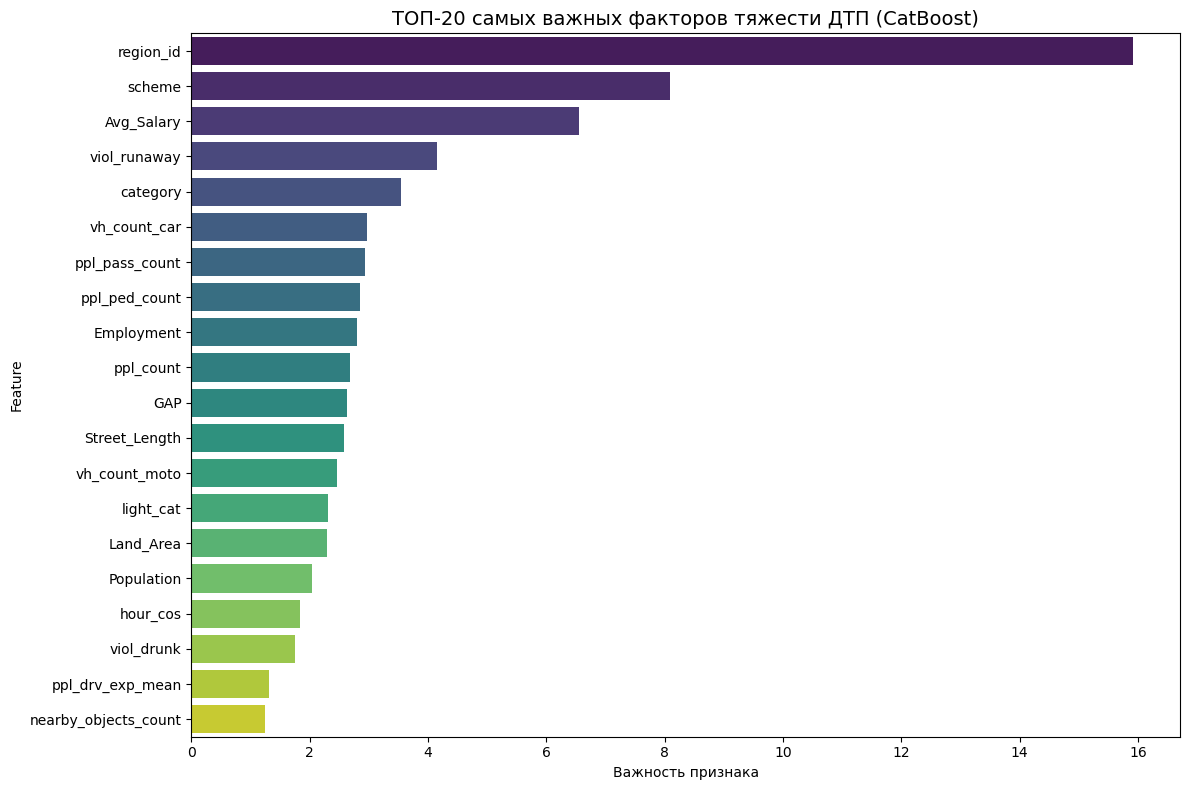


💾 Модель успешно сохранена: ../../data/processed\catboost_best_micro.cbm


In [ ]:
start_time = time.time()

base_dir = None
for p in ["../../data/processed", "../data/processed", "data/processed"]:
    if os.path.exists(p):
        base_dir = p
        break

micro_path = os.path.join(base_dir, "merged_micro.parquet")
print(f"Загрузка данных из: {micro_path}")
df = pd.read_parquet(micro_path)
print(f"Исходный размер: {df.shape}")

df['target_bin'] = (df['target'] >= 1).astype(int)
print("\nРаспределение нового таргета:")
print(df['target_bin'].value_counts(normalize=True).round(3))

cols_to_drop = [
    'target', 'target_bin', 
    'RTA_dead', 'RTA_serious', 'RTA_minor',
    'lat', 'long',                         
    'year'                                 
]
cols_to_drop = [c for c in cols_to_drop if c in df.columns]

X = df.drop(columns=cols_to_drop)
y = df['target_bin']

cat_features = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
X[cat_features] = X[cat_features].fillna('Missing').astype(str)

print(f"\nКоличество фичей для обучения: {X.shape[1]}")
print(f"Категориальных фичей: {len(cat_features)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cb_model = CatBoostClassifier(
    cat_features=cat_features,     # <--- ПЕРЕНЕСЛИ СЮДА!
    loss_function='Logloss',
    eval_metric='AUC',
    thread_count=-1,       
    auto_class_weights='Balanced', 
    early_stopping_rounds=30,      
    random_seed=42,
    verbose=0
)

grid = {
    'learning_rate': [0.03, 0.05, 0.1],
    'depth': [4, 6, 8],             
    'l2_leaf_reg': [1, 3, 5, 10],   
    'iterations': [500, 1000]       
}


search_result = cb_model.randomized_search(
    grid,
    X=X_train,
    y=y_train,
    cv=3,                 
    n_iter=12,            
    partition_random_seed=42,
    calc_cv_statistics=True,
    search_by_train_test_split=True,
    verbose=False,        
    plot=False
)

print("\nПЕРЕБОР ЗАВЕРШЕН!")
print(f"Время выполнения: {(time.time() - start_time) / 60:.1f} минут")
print("\nЛучшие гиперпараметры:")
for k, v in search_result['params'].items():
    print(f"  - {k}: {v}")

print("ОЦЕНКА НА ТЕСТОВОЙ ВЫБОРКЕ (Test Set)")
y_pred = cb_model.predict(X_test)
y_proba = cb_model.predict_proba(X_test)[:, 1]

print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
print("\nОтчет классификации:")
print(classification_report(y_test, y_pred))

feat_imp = cb_model.get_feature_importance(Pool(X_train, y_train, cat_features=cat_features))
importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feat_imp})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('ТОП-20 самых важных факторов тяжести ДТП (CatBoost)', fontsize=14)
plt.xlabel('Важность признака')
plt.tight_layout()
plt.show()

In [4]:
print(importance_df)

                 Feature  Importance
22             region_id   15.915162
1                 scheme    8.092354
88            Avg_Salary    6.556327
84          viol_runaway    4.154816
2               category    3.536935
54          vh_count_car    2.973334
68        ppl_pass_count    2.930999
69         ppl_ped_count    2.852414
89            Employment    2.802368
67             ppl_count    2.687524
87                   GAP    2.630781
90         Street_Length    2.582298
57         vh_count_moto    2.462817
0              light_cat    2.318695
91             Land_Area    2.299579
86            Population    2.045804
7               hour_cos    1.834526
81            viol_drunk    1.745405
76      ppl_drv_exp_mean    1.307048
21  nearby_objects_count    1.242046
